In [92]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from vollib.black_scholes.implied_volatility import implied_volatility
from vollib.black_scholes.greeks.analytical import delta, gamma, theta, vega, rho

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


%matplotlib inline

In [77]:
def load_data(path1, path2):
    
    df_spot = pd.read_parquet(f"{path1}") 
    df_strike = pd.read_parquet(f"{path2}")

    df_strike['Datetime'] = pd.to_datetime(df_strike['Datetime'])
    
    df_strike['Expiry_date'] = pd.to_datetime(df_strike['Expiry_date'])

    df_strike = df_strike[df_strike['Datetime'].dt.date == df_strike['Expiry_date'].dt.date]

    df_final = pd.merge(df_strike, df_spot, on='Datetime', how='left')

    df_final = df_final[abs(df_final['StrikePrice'] - df_final['Close_y']) <= (df_final['Close_y'] * 0.5 / 100)]

    df_final = df_final.drop(columns=['symbol_y', 'time_x', 'time_y'])

    df_final = df_final.rename({
        'symbol_x' : 'symbol',
        'Datetime': 'datetime',
        'Expiry_date': 'expiry_date',
        'Open_x': 'op_open',
        'High_x': 'op_high',
        'Low_x': 'op_low', 
        'Close_x': 'op_close',
        'Volume_x': 'op_volume',
        'OpenInterest': 'op_oi',
        'CE/PE': 'ce/pe',
        'Open_y': 'spot_open',
        'High_y': 'spot_high',
        'Low_y': 'spot_low',
        'Close_y': 'spot_close',
        'Volume_y': 'spot_volume',
    }, axis=1)

    df_final = df_final.sort_values('datetime')

    df_final.reset_index(drop=True, inplace=True)
    
    return df_final
    
spot_path = r"C:\Users\shubh\Desktop\Jupyter Notebooks\Data\Junomoneta\spots_2026\spots\nifty_minute_spot_May.gzip"
strike_path = r"C:\Users\shubh\Desktop\Jupyter Notebooks\Data\Junomoneta\strikes_2026\strikes\nifty_minute_May.gzip"

In [78]:
df_vix = pd.read_csv(r"C:\Users\shubh\Desktop\Jupyter Notebooks\Data\Junomoneta\vix\vix-apr-jul.csv")
df_vix.columns = df_vix.columns.str.strip()

In [79]:
df_final = load_data(spot_path, strike_path)

df_final.head()

,symbol,datetime,expiry_date,op_open,op_high,op_low,op_close,op_volume,op_oi,ce/pe,StrikePrice,spot_open,spot_high,spot_low,spot_close,spot_volume
0,NIFTY,2026-05-05 09:15:00,2026-05-05,187.60,199.00,90.80,133.20,1584830.0,774540.0,CE,23900.0,24055.6,24061.9,23949.4,24008.5,5112002.0
1,NIFTY,2026-05-05 09:15:00,2026-05-05,60.05,100.00,60.05,69.65,12774710.0,8007285.0,PE,24000.0,24055.6,24061.9,23949.4,24008.5,5112002.0
2,NIFTY,2026-05-05 09:15:00,2026-05-05,101.10,175.05,101.10,134.35,3996395.0,5470985.0,PE,24100.0,24055.6,24061.9,23949.4,24008.5,5112002.0
3,NIFTY,2026-05-05 09:15:00,2026-05-05,69.95,135.00,65.00,99.40,4310410.0,2676635.0,PE,24050.0,24055.6,24061.9,23949.4,24008.5,5112002.0
4,NIFTY,2026-05-05 09:15:00,2026-05-05,29.90,47.40,20.00,31.80,7463300.0,5371730.0,PE,23900.0,24055.6,24061.9,23949.4,24008.5,5112002.0


In [80]:
def time_to_expiry_years(row, expiry_close_time="15:30:00"):
    expiry_dt = pd.Timestamp.combine(row['expiry_date'].date(), pd.to_datetime(expiry_close_time).time())
    seconds_left = (expiry_dt - row['datetime']).total_seconds()
    return max(seconds_left, 1) / (365 * 24 * 3600)  # floor at 1 sec to avoid T=0

df_final['T'] = df_final.apply(time_to_expiry_years, axis=1)

r = 0.065  # approx Indian risk-free (91-day T-bill / repo proxy) — swap for actual if you have it

df_final['flag'] = df_final['ce/pe'].str.lower().str[0]  # 'c' or 'p'
df_final['mid_price'] = (df_final['op_high'] + df_final['op_low']) / 2  # more stable than close for a solver

def intrinsic(row):
    if row['flag'] == 'c':
        return max(row['spot_close'] - row['StrikePrice'], 0)
    else:
        return max(row['StrikePrice'] - row['spot_close'], 0)

df_final['intrinsic'] = df_final.apply(intrinsic, axis=1)
df_final['arbitrage_violation'] = df_final['mid_price'] < df_final['intrinsic']

In [81]:
def solve_iv(row):
    if row['arbitrage_violation'] or row['mid_price'] <= 0 or row['T'] <= 0:
        return np.nan
    try:
        return implied_volatility(row['mid_price'], row['spot_close'], row['StrikePrice'],
                                   row['T'], r, row['flag'])
    except Exception:
        return np.nan

df_final['iv'] = df_final.apply(solve_iv, axis=1)

In [83]:
df_final['date'] = df_final['datetime'].dt.date
vix_lookup = df_vix.set_index('Date')['Close'] / 100  # your VIX table, annualized decimal

needs_fallback = df_final['iv'].isna() & ~df_final['arbitrage_violation'] & (df_final['mid_price'] > 0)
df_final.loc[needs_fallback, 'iv'] = df_final.loc[needs_fallback, 'date'].map(vix_lookup)

df_final.loc[df_final['arbitrage_violation'], 'iv'] = np.nan  # leave these nan on purpose

In [84]:
def compute_greeks(row):
    if pd.isna(row['iv']) or row['iv'] <= 0 or row['T'] <= 0:
        return pd.Series([np.nan]*4, index=['delta','gamma','theta','vega'])
    args = (row['flag'], row['spot_close'], row['StrikePrice'], row['T'], r, row['iv'])
    return pd.Series([
        delta(*args),
        gamma(*args),
        theta(*args),
        vega(*args),
    ], index=['delta','gamma','theta','vega'])

df_final[['delta','gamma','theta','vega']] = df_final.apply(compute_greeks, axis=1)

In [88]:
def build_atm_series(df):
    df = df.copy()
    df['moneyness_dist'] = (df['StrikePrice'] - df['spot_close']).abs()

    # find the ATM strike at each minute (per day)
    atm_strike = (df.groupby('datetime')
                    .apply(lambda g: g.loc[g['moneyness_dist'].idxmin(), 'StrikePrice'])
                    .rename('atm_strike'))

    df = df.merge(atm_strike, on='datetime', how='left')
    df_atm = df[df['StrikePrice'] == df['atm_strike']].copy()

    # aggregate CE/PE at the ATM strike -> one row per minute
    agg = df_atm.groupby('datetime').agg(
        spot_close   = ('spot_close', 'first'),
        spot_open    = ('spot_open', 'first'),
        spot_high    = ('spot_high', 'first'),
        spot_low     = ('spot_low', 'first'),
        spot_volume  = ('spot_volume', 'first'),
        atm_strike   = ('atm_strike', 'first'),
        expiry_date  = ('expiry_date', 'first'),
        T            = ('T', 'first'),
        iv           = ('iv', 'mean'),
        delta        = ('delta', 'mean'),
        gamma        = ('gamma', 'mean'),
        theta        = ('theta', 'mean'),
        vega         = ('vega', 'mean'),
        op_oi        = ('op_oi', 'sum'),      # CE+PE combined OI at ATM
        op_volume    = ('op_volume', 'sum'),  # CE+PE combined volume at ATM
    ).reset_index()

    agg['date'] = agg['datetime'].dt.date
    return agg.sort_values('datetime').reset_index(drop=True)

atm_df = build_atm_series(df_final)
print(atm_df.isna().sum())

datetime       0
spot_close     0
spot_open      0
spot_high      0
spot_low       0
spot_volume    0
atm_strike     0
expiry_date    0
T              0
iv             0
delta          0
gamma          0
theta          0
vega           0
op_oi          0
op_volume      0
date           0
dtype: int64


C:\Users\shubh\AppData\Local\Temp\ipykernel_7016\1593706162.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g['moneyness_dist'].idxmin(), 'StrikePrice'])


In [89]:
greek_cols = ['iv', 'delta', 'gamma', 'theta', 'vega']

# ffill within each day only — never bleed values across day boundaries
atm_df[greek_cols] = atm_df.groupby('date')[greek_cols].ffill()
atm_df[greek_cols] = atm_df.groupby('date')[greek_cols].bfill()  # catches a NaN at 09:15 open

print(atm_df.isna().sum())  # should be 0 now

datetime       0
spot_close     0
spot_open      0
spot_high      0
spot_low       0
spot_volume    0
atm_strike     0
expiry_date    0
T              0
iv             0
delta          0
gamma          0
theta          0
vega           0
op_oi          0
op_volume      0
date           0
dtype: int64


In [90]:
def engineer_features(df):
    df = df.copy()
    df = df.sort_values('datetime').reset_index(drop=True)

    lags = [1, 2, 3, 5, 10, 15]
    for lag in lags:
        df[f'gamma_lag_{lag}'] = df.groupby('date')['gamma'].shift(lag)

    windows = [5, 10, 15, 30]
    for w in windows:
        df[f'gamma_roll_mean_{w}'] = df.groupby('date')['gamma'].transform(
            lambda s: s.rolling(w, min_periods=1).mean())
        df[f'gamma_roll_std_{w}'] = df.groupby('date')['gamma'].transform(
            lambda s: s.rolling(w, min_periods=1).std())

    # spot dynamics
    df['spot_ret_1'] = df.groupby('date')['spot_close'].pct_change(1)
    df['spot_ret_5'] = df.groupby('date')['spot_close'].pct_change(5)
    df['spot_roll_std_10'] = df.groupby('date')['spot_close'].transform(
        lambda s: s.rolling(10, min_periods=1).std())

    # time-to-expiry features -- crucial since gamma explodes as T->0
    df['minutes_to_expiry'] = df['T'] * 365 * 24 * 60
    df['inv_sqrt_T'] = 1 / np.sqrt(df['T'].clip(lower=1e-6))

    # other greeks/state as-of-t (not future leaking)
    df['iv_lag_1'] = df.groupby('date')['iv'].shift(0)  # current iv is fine, it's known at t
    df['oi_lag_1'] = df.groupby('date')['op_oi'].shift(0)
    df['vol_lag_1'] = df.groupby('date')['op_volume'].shift(0)

    # TARGET: next-minute gamma, never crossing day boundary
    df['gamma_target'] = df.groupby('date')['gamma'].shift(-1)

    return df

feat_df = engineer_features(atm_df)

feature_cols = [c for c in feat_df.columns if c.startswith(('gamma_lag', 'gamma_roll',
                'spot_ret', 'spot_roll'))] + \
               ['iv', 'delta', 'theta', 'vega', 'spot_close', 'op_oi', 'op_volume',
                'minutes_to_expiry', 'inv_sqrt_T']

# drop rows with NaN from lag/rolling warmup or missing target (last row of each day)
model_df = feat_df.dropna(subset=feature_cols + ['gamma_target']).reset_index(drop=True)

In [91]:
test_date = pd.to_datetime('2026-05-26').date()

train_df = model_df[model_df['date'] != test_date]
test_df  = model_df[model_df['date'] == test_date]

X_train, y_train = train_df[feature_cols], train_df['gamma_target']
X_test,  y_test  = test_df[feature_cols],  test_df['gamma_target']

print(train_df['date'].unique(), test_df.shape)

[datetime.date(2026, 5, 5) datetime.date(2026, 5, 12)
 datetime.date(2026, 5, 19)] (359, 40)


In [97]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

MAE : 0.0033465084024184217
RMSE: 0.025901689464134552


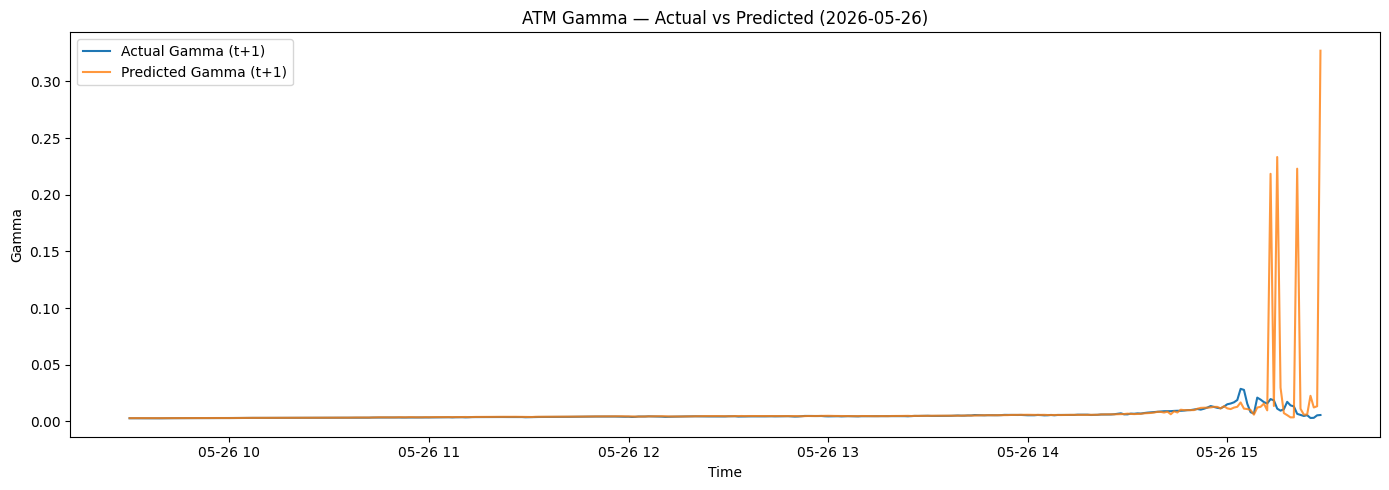

In [96]:

plt.figure(figsize=(14,5))
plt.plot(test_df['datetime'], y_test.values, label='Actual Gamma (t+1)', linewidth=1.5)
plt.plot(test_df['datetime'], pred, label='Predicted Gamma (t+1)', linewidth=1.5, alpha=0.8)
plt.title('ATM Gamma — Actual vs Predicted (2026-05-26)')
plt.xlabel('Time'); plt.ylabel('Gamma')
plt.legend(); plt.tight_layout()
plt.show()

In [95]:
import pandas as pd
imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(imp.head(15))

gamma_lag_3           0.192179
theta                 0.146475
delta                 0.122770
spot_ret_5            0.117043
gamma_lag_2           0.095893
gamma_roll_std_15     0.068071
gamma_roll_std_5      0.057145
gamma_roll_std_10     0.032254
gamma_lag_1           0.031187
gamma_roll_mean_5     0.030146
iv                    0.028400
spot_ret_1            0.013584
inv_sqrt_T            0.013233
minutes_to_expiry     0.011744
gamma_roll_mean_15    0.010816
dtype: float32


In [98]:
def walk_forward_validate(model_df, feature_cols, target_col='gamma_target',
                           min_train_days=3):
    dates = sorted(model_df['date'].unique())
    results = []
    predictions_all = []

    for i in range(min_train_days, len(dates)):
        test_date = dates[i]
        train_dates = dates[:i]        

        train = model_df[model_df['date'].isin(train_dates)]
        test  = model_df[model_df['date'] == test_date]

        if train.empty or test.empty:
            continue

        X_train, y_train = train[feature_cols], train[target_col]
        X_test,  y_test  = test[feature_cols],  test[target_col]

        model = XGBRegressor(
            n_estimators=500, max_depth=5, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            random_state=42, n_jobs=-1,
        )
        model.fit(X_train, y_train, verbose=False)
        pred = model.predict(X_test)

        mae  = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2   = r2_score(y_test, pred)

        results.append({
            'test_date': test_date, 'n_train_days': len(train_dates),
            'n_train_rows': len(train), 'n_test_rows': len(test),
            'MAE': mae, 'RMSE': rmse, 'R2': r2
        })

        pred_df = test[['datetime', 'date', target_col]].copy()
        pred_df['predicted'] = pred
        predictions_all.append(pred_df)

    results_df = pd.DataFrame(results)
    all_preds_df = pd.concat(predictions_all, ignore_index=True)
    return results_df, all_preds_df

results_df, all_preds_df = walk_forward_validate(model_df, feature_cols, min_train_days=3)
print(results_df)
print("\nAverage across all test days:")
print(results_df[['MAE','RMSE','R2']].mean())

    test_date  n_train_days  n_train_rows  n_test_rows       MAE      RMSE  \
0  2026-05-26             3          1077          359  0.003347  0.025902   

          R2  
0 -53.465948  

Average across all test days:
MAE      0.003347
RMSE     0.025902
R2     -53.465948
dtype: float64
